# **Worksheet 1 - Image Compression and Decompression using PCA.**

Student Name : Sujal Shrestha

Student Number: 2357917

In [4]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Exercise - 1:

1. Read and display the image.

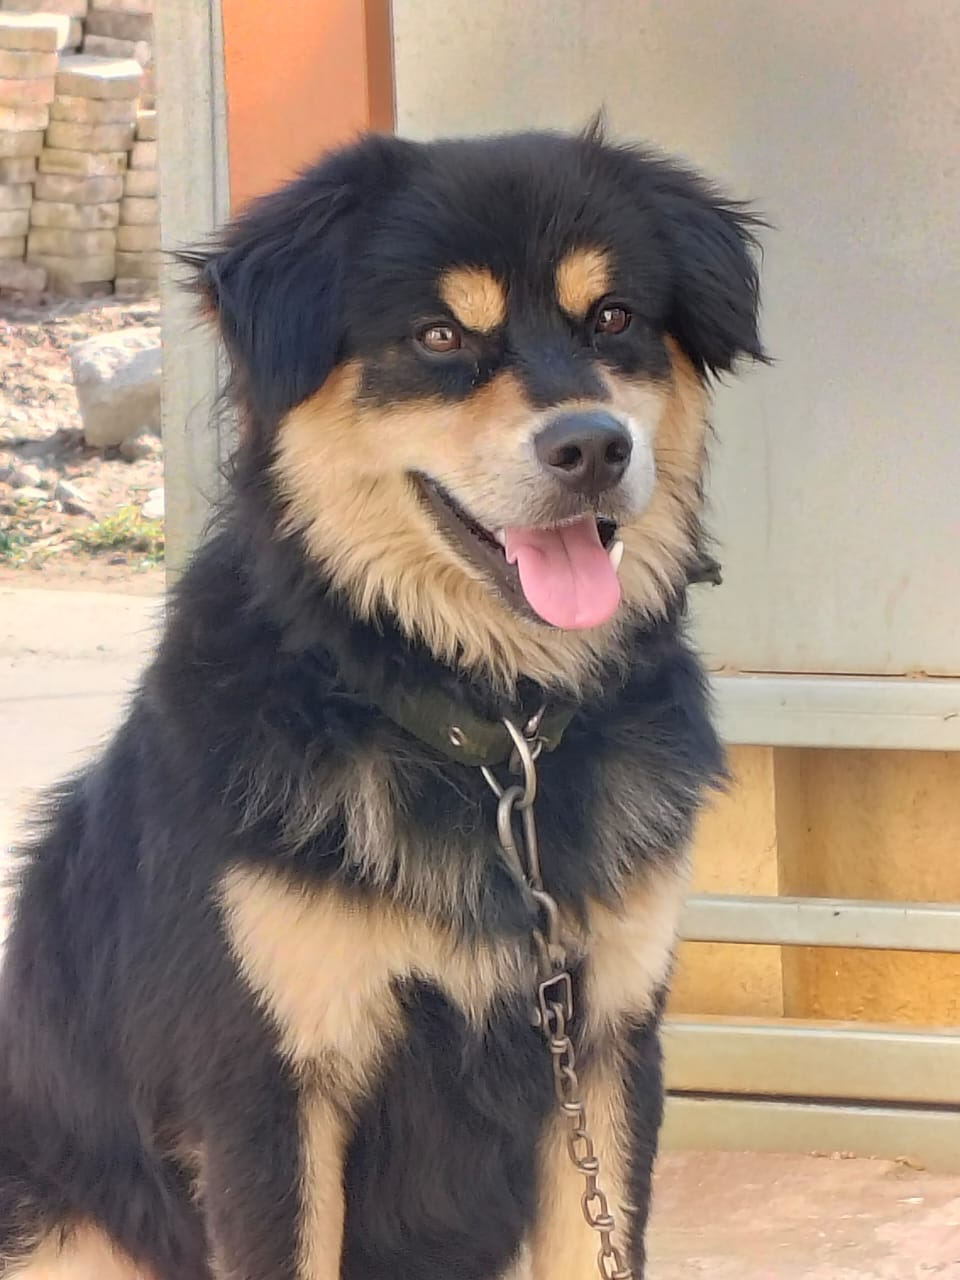

In [6]:
img = Image.open("imag.jpg")
display (img)


2. Display only the top left corner of 100x100 pixels.

In [7]:
img_array = np.array(img)
top_left = img_array[0:100, 0:100]

display(top_left)

array([[[140, 135, 113],
        [149, 144, 122],
        [165, 157, 136],
        ...,
        [223, 197, 170],
        [230, 204, 177],
        [233, 207, 180]],

       [[143, 137, 115],
        [151, 145, 123],
        [166, 158, 137],
        ...,
        [220, 194, 167],
        [228, 202, 175],
        [230, 204, 177]],

       [[146, 138, 117],
        [155, 147, 126],
        [169, 158, 136],
        ...,
        [217, 193, 167],
        [223, 199, 173],
        [227, 203, 177]],

       ...,

       [[237, 190, 146],
        [237, 190, 146],
        [238, 191, 149],
        ...,
        [174, 144, 116],
        [174, 144, 116],
        [172, 142, 114]],

       [[231, 187, 142],
        [232, 188, 143],
        [234, 187, 145],
        ...,
        [152, 122,  94],
        [152, 122,  94],
        [151, 121,  93]],

       [[229, 185, 140],
        [229, 185, 140],
        [232, 185, 143],
        ...,
        [145, 115,  87],
        [144, 114,  86],
        [143, 113,  85]]

3. Show R, G, B color channels


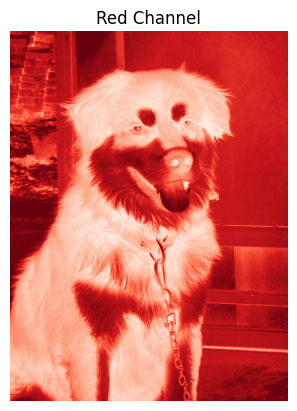

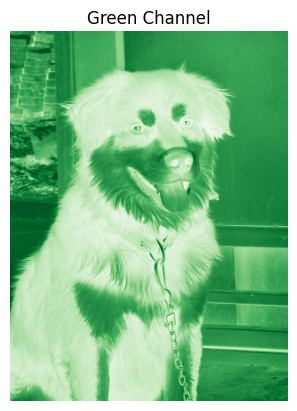

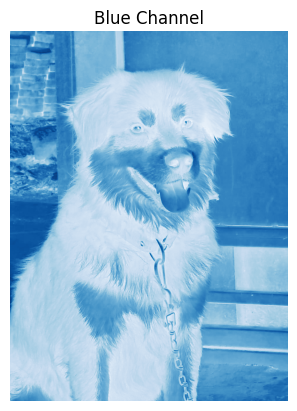

In [8]:
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

# Red channel
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")
plt.show()

# Green channel
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")
plt.show()

# Blue channel
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")
plt.show()

# The display() function does not reliably show R, G, B channels here
# because these channels are 2D NumPy arrays (height x width) and not full RGB images.
# display() works automatically for full images (with 3 channels) or PIL Image objects,
# so for single channels we use matplotlib's imshow() to properly visualize them.

4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:

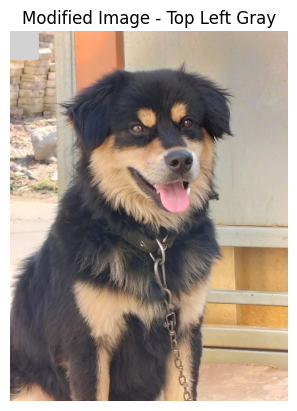

In [9]:
top_left[:, :, :] = 210   # all 3 channels

# Put the modified top-left back into the image array
img_array[0:100, 0:100] = top_left

# Display the modified image
plt.imshow(img_array)
plt.title("Modified Image - Top Left Gray")
plt.axis("off")
plt.show()

# Exercise - 2:

1. Load and display a grayscale image.

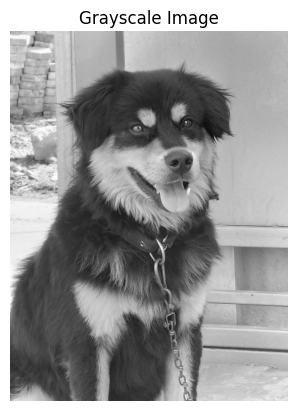

In [12]:
# Reload the colored image
img_colored = Image.open("imag.jpg")

# Convert the image to grayscale
img_gray = img_colored.convert("L")  # "L" mode = grayscale

# Display the grayscale image using matplotlib
plt.imshow(img_gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

2. Extract and display the middle section of the image (150 pixels).

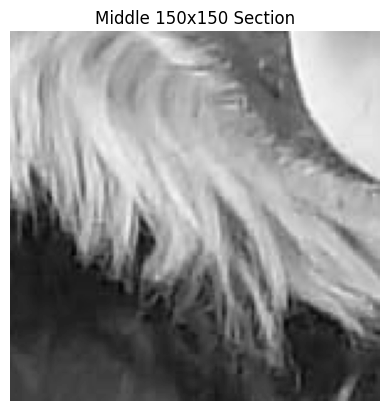

In [13]:
img_array = np.array(img_gray)

height, width = img_array.shape

# Calculate the center coordinates
center_y = height // 2
center_x = width // 2

# Calculate the start and end indices for a 150x150 section
half_size = 150 // 2
start_y = center_y - half_size
end_y = center_y + half_size
start_x = center_x - half_size
end_x = center_x + half_size

# Extract the middle 150x150 section
middle_section = img_array[start_y:end_y, start_x:end_x]

plt.imshow(middle_section, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).

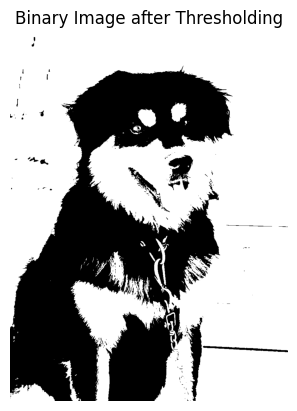

In [14]:
# Apply threshold: pixels < 100 : 0, pixels >= 100 : 255
threshold_value = 100
binary_image = np.where(img_array < threshold_value, 0, 255)

plt.imshow(binary_image, cmap="gray")
plt.title("Binary Image after Thresholding")
plt.axis("off")
plt.show()

4. Rotate the image 90 degrees clockwise and display the result.

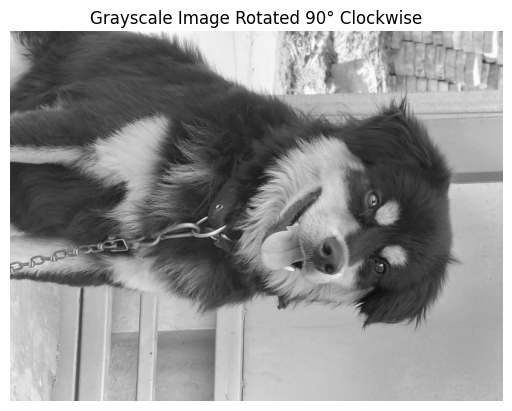

In [15]:
# Rotate the grayscale image 90 degrees clockwise using Pillow
rotated_img = img_gray.rotate(-90, expand=True)  # -90 for clockwise

plt.imshow(rotated_img, cmap="gray")
plt.title("Grayscale Image Rotated 90° Clockwise")
plt.axis("off")
plt.show()

5. Convert the grayscale image to an RGB image.

This creates a 3-channel image even though we started with grayscale.

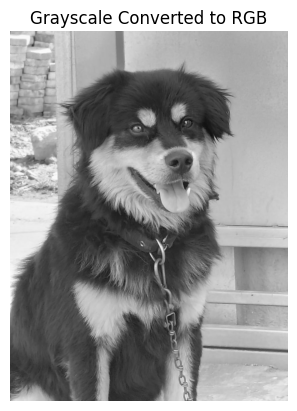

In [16]:
# Stack the grayscale array into 3 channels (R, G, B)
img_array = np.stack((img_array,)*3, axis=-1)

rgb_image = Image.fromarray(img_array)

plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

# Exercise - 3:

Image Compression and Decompression using PCA.

1. Load and Prepare Data:

In [17]:
# Load a colored image and convert to grayscale
image_colored = Image.open("imag.jpg")
image_gray = image_colored.convert("L")  # convert to grayscale

# Convert to NumPy array
image_array = np.array(image_gray, dtype=float)
print("Shape of grayscale image:", image_array.shape)

# Center the data (subtract mean)
mean = np.mean(image_array, axis=0)
centered_data = image_array - mean
print("Shape of centered data:", centered_data.shape)

# Compute covariance matrix
cov_matrix = np.cov(centered_data, rowvar=False)
print("Covariance matrix shape:", cov_matrix.shape)

Shape of grayscale image: (1280, 960)
Shape of centered data: (1280, 960)
Covariance matrix shape: (960, 960)


2. Eigen Decomposition and Identifying Principal Components:

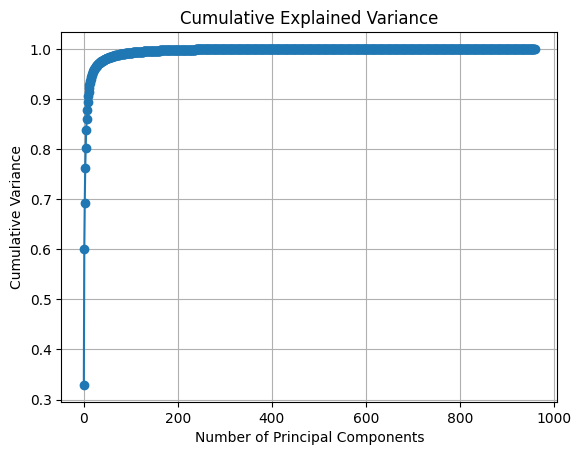

Shape of top k components: (960, 50)


In [18]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)  # covariance is symmetric

# Sort eigenvalues and eigenvectors in descending order
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

# Cumulative explained variance
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot cumulative variance
plt.plot(cumulative_variance, marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance")
plt.grid(True)
plt.show()

# Choose top k components (e.g., k=50)
k = 50
components = eigenvectors[:, :k]
print("Shape of top k components:", components.shape)

3. Reconstruction and Experiment:

Shape of compressed data: (1280, 50)
Shape of decompressed data: (1280, 960)


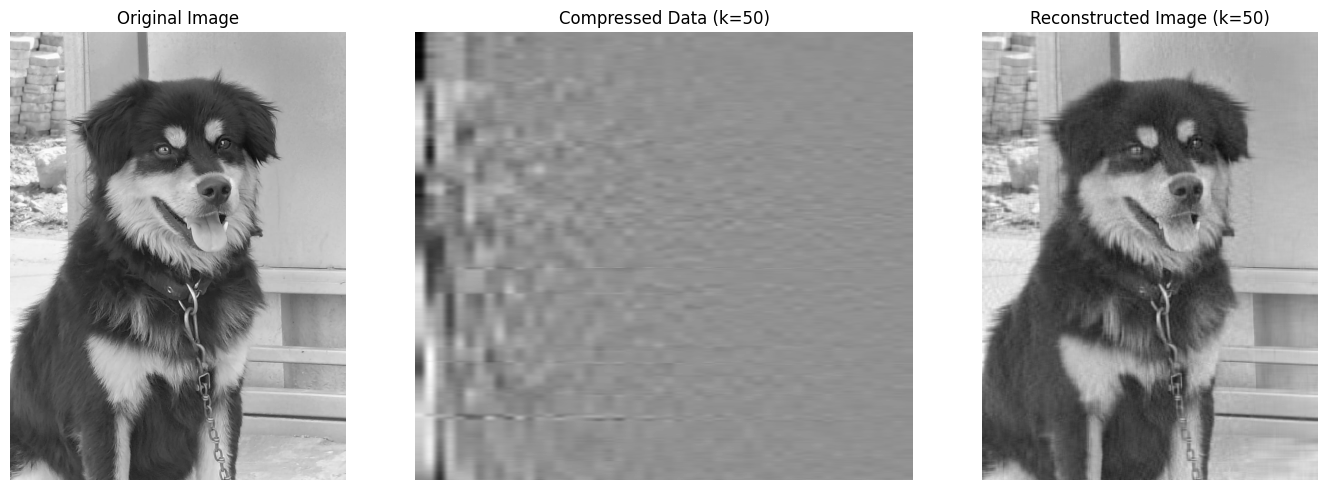

In [19]:
# Compress the data
compressed_data = np.dot(centered_data, components)
print("Shape of compressed data:", compressed_data.shape)

# Reconstruct the image
decompressed_data = np.dot(compressed_data, components.T) + mean
print("Shape of decompressed data:", decompressed_data.shape)

# Display original, compressed, and reconstructed images
plt.figure(figsize=(15,5))

# Original Image
plt.subplot(1,3,1)
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Compressed Representation
plt.subplot(1,3,2)
plt.imshow(compressed_data, cmap="gray", aspect='auto')
plt.title(f"Compressed Data (k={k})")
plt.axis("off")

# Reconstructed Image
plt.subplot(1,3,3)
plt.imshow(decompressed_data, cmap="gray")
plt.title(f"Reconstructed Image (k={k})")
plt.axis("off")

plt.tight_layout()
plt.show()